# Goal

Compare the linear viral transcript (`pSL-NtermF-DS`, GEX) to the oBC barcode UMI
counts (`bc` modality, 18 barcodes across 8 pooled cargo genes) per cell, the SIG02
analog of SIG03's `jointplot_viral_vs_BC4/BC5` figures in `barcode_viz_CD4.ipynb`.
ROC/AUC classification is out of scope here (see `processing/scanpy_processing_SIG02.ipynb`).

**`control` is not an untransduced/no-virus condition** -- it's a real virus, a
linker-only `NtermF` vLP (same construct as the `NtermF` barcode / `pSL-NtermF-DS`
transcript), delivered instead of the pooled cargo-gene library. So `control` cells
are expected to show viral transcript and `NtermF`-barcode signal too; they are not a
detection-background baseline the way SIG03's `0`-titer control is.

Four figures:

1. **Joint plot**, viral UMIs (x) vs. total oBC UMIs (y, summed across all 18
   barcodes), faceted by `condition` (`lib` / `control`) x `timepoint` (`24h` / `6h`).
2. **Joint plot per cargo gene**, `lib` cells only, to see whether detection differs
   by construct (`NtermF`, `mIL1b`, `mIL2`, `mIL4`, `mIL6`, `mIL12`, `mIFNy`, `mTGFb`).
3. **`NtermF`-specific joint plot, `lib` vs. `control`** -- `NtermF` is the one
   construct delivered in *both* conditions (as part of the pooled library, and alone
   as the linker-only control vLP), so it's the direct apples-to-apples comparison of
   detection between the two delivery conditions.
4. **oBC UMI counts across ligands** -- a violin plot comparing each cargo gene's oBC
   UMI distribution side by side (`lib` cells, faceted by timepoint), i.e. which
   ligand's barcode is delivered/detected most efficiently. `NtermF` is included for
   reference but is the linker-only construct, not a ligand.

## Packages

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/01_barcode_comparison_signalseq_SIG02_SIG03"

import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, f"{REPO_DIR}/functions")
import scanpy_custom as scc

sc.settings.verbosity = 1
sns.set_theme(style="ticks")

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Paths

In [2]:
OUT_DIR = f"{IMPORTS_DIR}/SIG02/scanpy_outs"
FULL_H5MU = os.path.join(OUT_DIR, "SIG02_full.h5mu")

ANALYSIS_OUTS = OUTS_DIR
os.makedirs(ANALYSIS_OUTS, exist_ok=True)

## Load data and assemble per-cell predictor table

One row per cell with `condition` / `timepoint` / `method`, the viral transcript's raw
UMI count, each of the 18 oBC barcodes, `oBC_total` (row-sum across all 18), and a
per-cargo-gene sum (grouping barcode replicates, e.g. `NtermF_BC1..BC4` -> `NtermF`,
`mIL2_BC1`+`mIL2_BC2` -> `mIL2`, by stripping the trailing `_BC<n>` from the feature
name).

In [3]:
def feature_counts(adata, feat, layer="counts"):
    sub = adata[:, feat]
    X = sub.layers[layer] if layer in sub.layers else sub.X
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    return X.ravel()

mdata = mu.read(FULL_H5MU)
rna = mdata.mod["rna"]
bc = mdata.mod["bc"]

df = rna.obs[["condition", "timepoint", "method"]].copy()

# oBC predictors (raw UMI counts), one column per barcode, aligned by cell barcode
bc_counts = pd.DataFrame(
    bc.layers["counts"].toarray() if hasattr(bc.layers["counts"], "toarray") else np.asarray(bc.layers["counts"]),
    index=bc.obs_names, columns=bc.var_names,
)
df = df.join(bc_counts)
df["oBC_total"] = bc_counts.sum(axis=1)

# per-cargo-gene sums (strip trailing _BC<n> from the barcode feature name)
gene_of = {b: re.sub(r"_BC\d+$", "", b) for b in bc.var_names}
GENES = sorted(set(gene_of.values()))
for gene in GENES:
    cols = [b for b, g in gene_of.items() if g == gene]
    df[gene] = bc_counts[cols].sum(axis=1)

# viral transcript: auto-detect the pSL-* gene in the GEX modality
viral_genes = [g for g in rna.var_names if g.startswith("pSL-")]
assert viral_genes, "No 'pSL-*' viral transcript found in rna.var_names."
viral_gene = viral_genes[0]
print(f"Detected viral transcript: {viral_gene}"
      + (f"  (others: {viral_genes[1:]})" if len(viral_genes) > 1 else ""))
df["viral"] = feature_counts(rna, viral_gene)

CONDITIONS = ["control", "lib"]
TIMEPOINTS = ["24h", "6h"]
print("cells:", len(df), "| cargo genes:", GENES)
df.groupby(["condition", "timepoint"], observed=True).size()

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Detected viral transcript: pSL-NtermF-DS
cells: 22360 | cargo genes: ['NtermF', 'mIFNy', 'mIL12', 'mIL1b', 'mIL2', 'mIL4', 'mIL6', 'mTGFb']


condition  timepoint
control    6h            1013
           24h           1389
lib        6h            8234
           24h          11724
dtype: int64

## 1. Joint plot: viral transcript vs. total oBC UMIs

Per-cell viral-transcript UMIs vs. total oBC UMIs (summed across all 18 barcodes), on
`log1p` axes, faceted by `condition` x `timepoint`. Both `lib` and `control` deliver a
real virus (pooled cargo library vs. linker-only `NtermF` vLP respectively) -- `control`
is not expected to be signal-free.

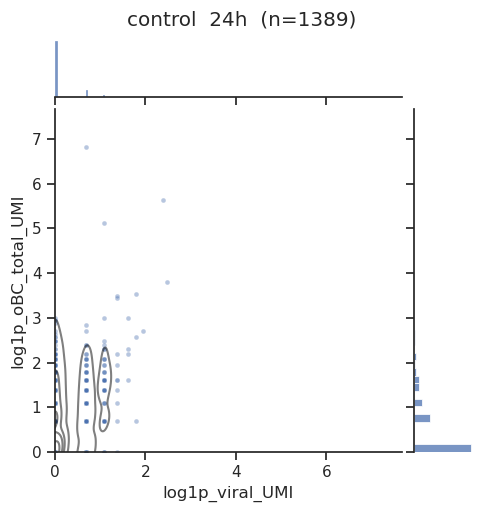

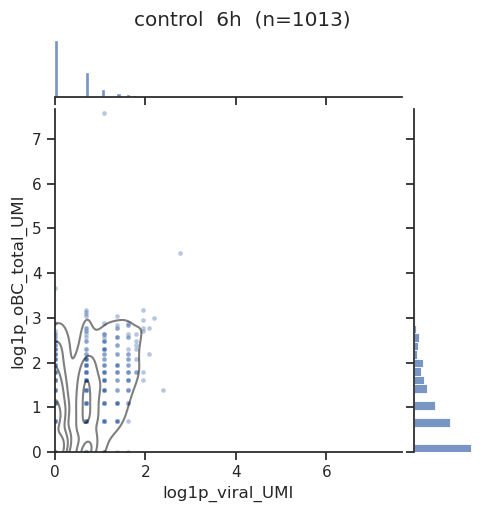

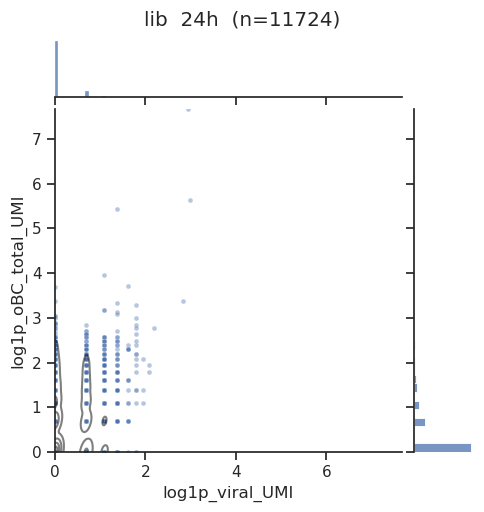

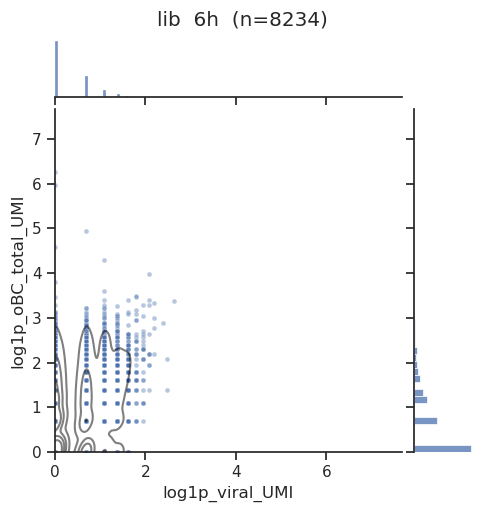

In [4]:
# shared square limits across all panels so they're directly comparable
jlim = float(np.log1p(df[["viral", "oBC_total"]].to_numpy()).max())

for cond in CONDITIONS:
    for tp in TIMEPOINTS:
        d = df[(df["condition"] == cond) & (df["timepoint"] == tp)]
        if len(d) == 0:
            continue
        plot_d = pd.DataFrame({
            "log1p_viral_UMI": np.log1p(d["viral"].to_numpy()),
            "log1p_oBC_total_UMI": np.log1p(d["oBC_total"].to_numpy()),
        })
        g = sns.jointplot(
            data=plot_d, x="log1p_viral_UMI", y="log1p_oBC_total_UMI",
            kind="scatter", height=5, alpha=0.4, s=12, marginal_kws=dict(bins=40),
            xlim=(0, jlim), ylim=(0, jlim),
        )
        g.plot_joint(sns.kdeplot, color="black", levels=5, alpha=0.5)
        g.figure.suptitle(f"{cond}  {tp}  (n={len(d)})", y=1.02)
        g.savefig(os.path.join(ANALYSIS_OUTS, f"jointplot_viral_vs_oBC_total_{cond}_{tp}.pdf"),
                  bbox_inches="tight")
        plt.show()

## 2. Joint plot per cargo gene (lib cells only)

Same viral-vs-oBC comparison, one panel per cargo gene (`lib` cells pooled across
timepoint/method), to see whether detection differs by construct.

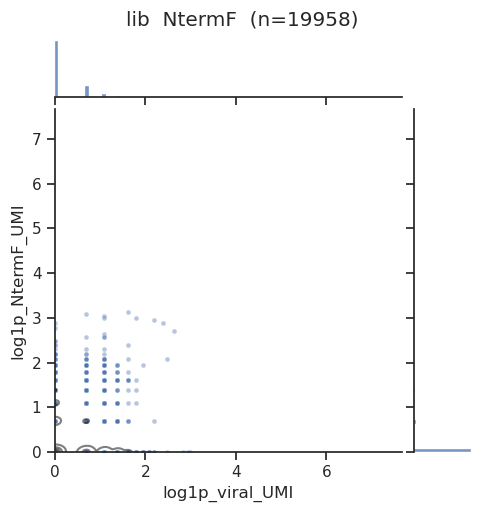

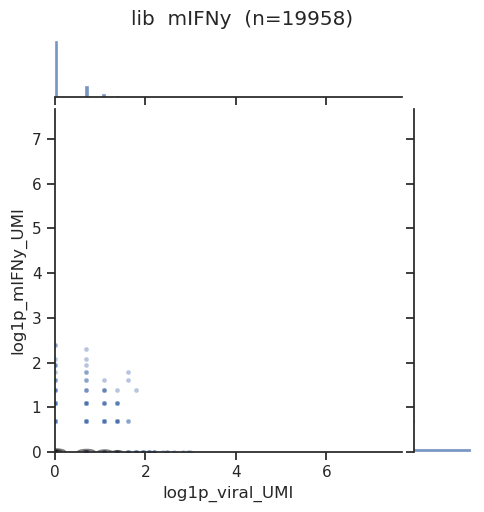

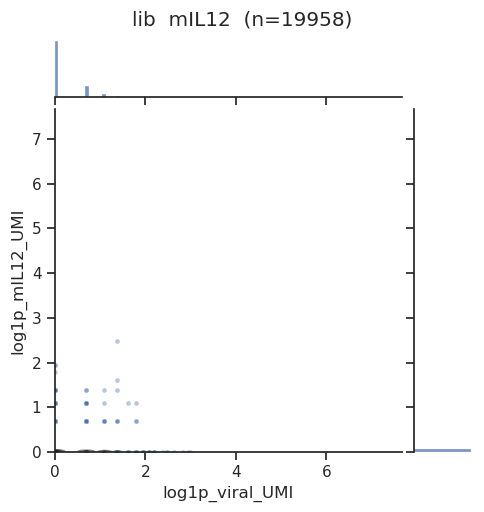

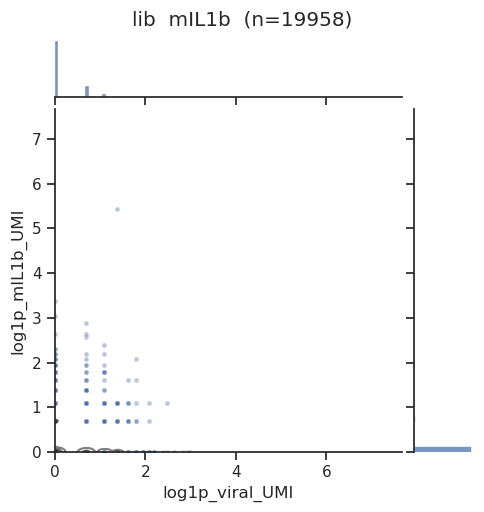

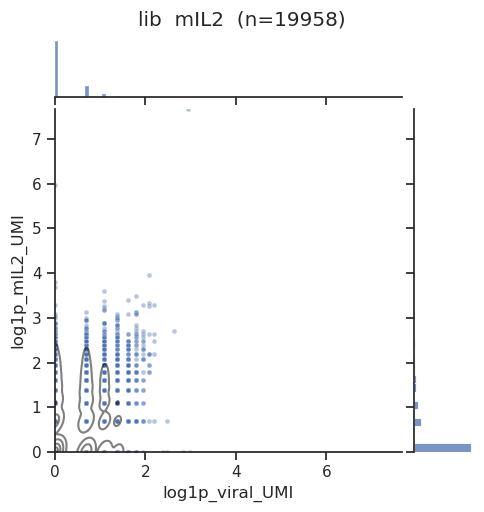

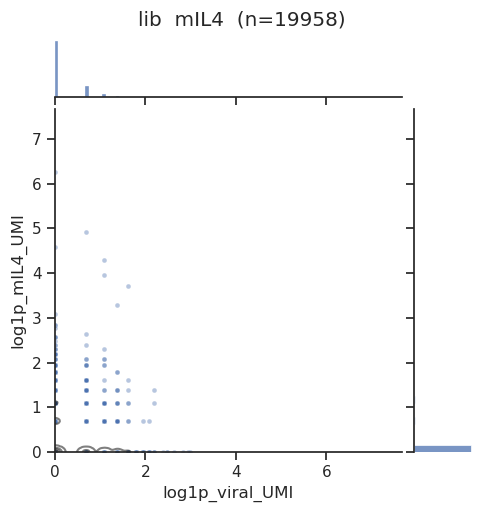

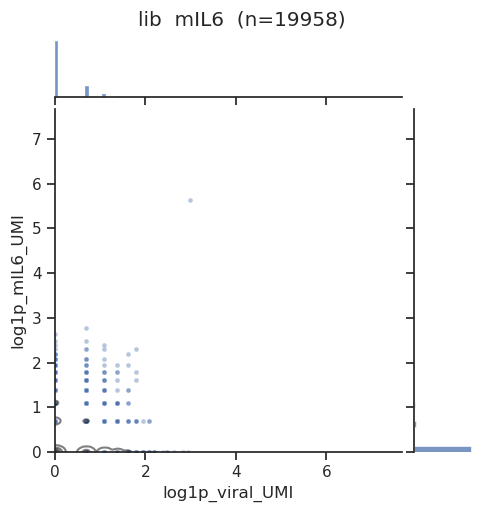

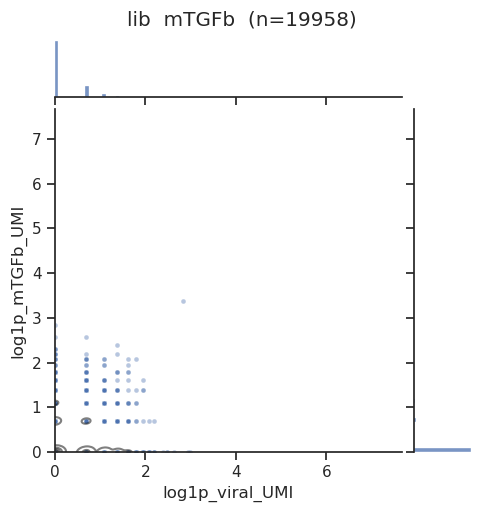

In [5]:
lib_df = df[df["condition"] == "lib"]
gene_jlim = float(np.log1p(lib_df[["viral"] + GENES].to_numpy()).max())

for gene in GENES:
    plot_d = pd.DataFrame({
        "log1p_viral_UMI": np.log1p(lib_df["viral"].to_numpy()),
        f"log1p_{gene}_UMI": np.log1p(lib_df[gene].to_numpy()),
    })
    g = sns.jointplot(
        data=plot_d, x="log1p_viral_UMI", y=f"log1p_{gene}_UMI",
        kind="scatter", height=5, alpha=0.4, s=12, marginal_kws=dict(bins=40),
        xlim=(0, gene_jlim), ylim=(0, gene_jlim),
    )
    g.plot_joint(sns.kdeplot, color="black", levels=5, alpha=0.5)
    g.figure.suptitle(f"lib  {gene}  (n={len(lib_df)})", y=1.02)
    g.savefig(os.path.join(ANALYSIS_OUTS, f"jointplot_viral_vs_oBC_{gene}.pdf"), bbox_inches="tight")
    plt.show()

## 3. `NtermF`-specific joint plot: `lib` vs. `control`

`NtermF` is the linker-only construct used as the dedicated `control` vLP, so unlike
the other 7 cargo genes it is (potentially) present in both conditions. Plotting it
with `condition` as a facet directly tests whether detection differs between the
pooled-library delivery and the standalone linker-only delivery of the same
construct.

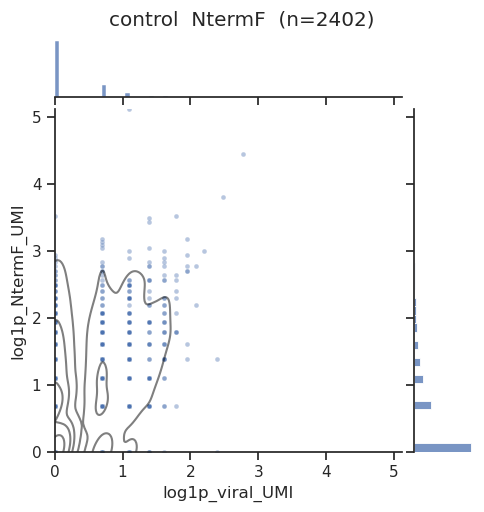

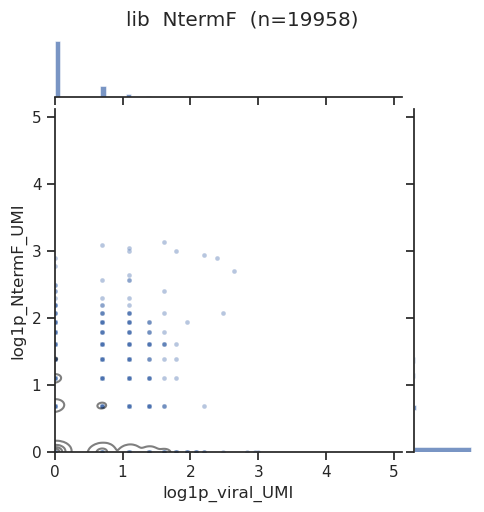

In [6]:
ntermf_jlim = float(np.log1p(df[["viral", "NtermF"]].to_numpy()).max())

for cond in CONDITIONS:
    d = df[df["condition"] == cond]
    plot_d = pd.DataFrame({
        "log1p_viral_UMI": np.log1p(d["viral"].to_numpy()),
        "log1p_NtermF_UMI": np.log1p(d["NtermF"].to_numpy()),
    })
    g = sns.jointplot(
        data=plot_d, x="log1p_viral_UMI", y="log1p_NtermF_UMI",
        kind="scatter", height=5, alpha=0.4, s=12, marginal_kws=dict(bins=40),
        xlim=(0, ntermf_jlim), ylim=(0, ntermf_jlim),
    )
    g.plot_joint(sns.kdeplot, color="black", levels=5, alpha=0.5)
    g.figure.suptitle(f"{cond}  NtermF  (n={len(d)})", y=1.02)
    g.savefig(os.path.join(ANALYSIS_OUTS, f"jointplot_viral_vs_oBC_NtermF_{cond}.pdf"), bbox_inches="tight")
    plt.show()

## 4. oBC UMI counts across ligands (`lib` cells)

Per-cell oBC UMI counts (raw, `log1p`) for each cargo gene side by side, `lib` cells
only (the pooled library is only delivered there), faceted by timepoint and ordered by
overall median UMI so the best- and worst-detected ligands are easy to spot. `NtermF`
is shown for reference (the linker-only construct) but is not itself a ligand.

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


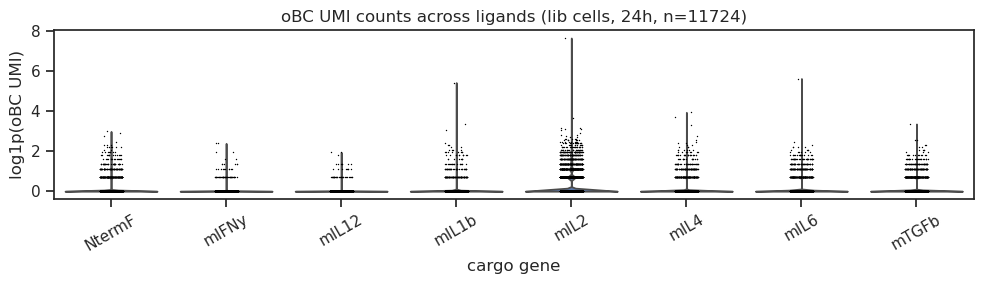

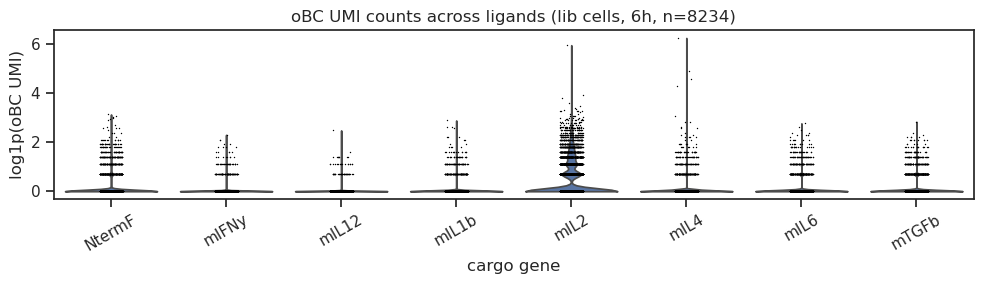

,gene,timepoint,n_cells,median_umi,frac_detected,frac_detected_umi2,frac_detected_umi5
0,NtermF,6h,8234,0.0,0.080398,0.027569,0.007044
1,NtermF,24h,11724,0.0,0.037786,0.007591,0.001962
2,mIFNy,6h,8234,0.0,0.018339,0.002672,0.000607
3,mIFNy,24h,11724,0.0,0.005629,0.001024,0.000341
4,mIL12,6h,8234,0.0,0.008380,0.001214,0.000121
5,mIL12,24h,11724,0.0,0.004179,0.000853,0.000171
6,mIL1b,6h,8234,0.0,0.032912,0.006680,0.001336
7,mIL1b,24h,11724,0.0,0.019021,0.004862,0.001706
8,mIL2,6h,8234,0.0,0.362278,0.155696,0.054287
9,mIL2,24h,11724,0.0,0.158649,0.050921,0.014927


In [9]:
gene_order = (lib_df[GENES].median().sort_values(ascending=False).index.tolist())

gene_adata = sc.AnnData(
    X=np.log1p(lib_df[GENES].to_numpy()),
    obs=lib_df[["timepoint"]].reset_index(drop=True),
    var=pd.DataFrame(index=GENES),
)

for tp in TIMEPOINTS:
    sub = gene_adata[gene_adata.obs["timepoint"] == tp]
    if sub.n_obs == 0:
        continue
    fig, ax = plt.subplots(figsize=(10, 3))
    sc.pl.violin(
        sub, keys=gene_order, groupby=None, order=gene_order, use_raw=False,
        density_norm="width", ylabel="log1p(oBC UMI)", rotation=30,
        show=False, ax=ax,
    )
    ax.set_xlabel("cargo gene")
    ax.set_title(f"oBC UMI counts across ligands (lib cells, {tp}, n={sub.n_obs})")
    fig.tight_layout()
    fig.savefig(os.path.join(ANALYSIS_OUTS, f"violin_oBC_umi_by_ligand_lib_{tp}.pdf"), bbox_inches="tight")
    plt.show()

# summary table: median UMI and detection rate per gene x timepoint
ligand_long = lib_df.melt(
    id_vars=["timepoint"], value_vars=GENES, var_name="gene", value_name="umi",
)
ligand_summary = ligand_long.groupby(["gene", "timepoint"], observed=True).agg(
    n_cells=("umi", "size"),
    median_umi=("umi", "median"),
    frac_detected=("umi", lambda x: float((x > 0).mean())),
    frac_detected_umi2 = ("umi", lambda x: float((x > 2).mean())),
    frac_detected_umi5 = ("umi", lambda x: float((x > 5).mean()))
).reset_index().sort_values(["gene", "timepoint"])
ligand_summary.to_csv(os.path.join(ANALYSIS_OUTS, "ligand_umi_summary_lib.csv"), index=False)
ligand_summary